<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day3_Exercises_XP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Exercice 1 : Utilisation de base de SciPy
# Objectif : importer la librairie et explorer sa version

import scipy

# Affichage de la version de SciPy installée
print("Version de SciPy :", scipy.__version__)

# Bonus : on peut aussi vérifier les sous-modules disponibles
print("Emplacement du module :", scipy.__file__)

Version de SciPy : 1.16.3
Emplacement du module : /usr/local/lib/python3.12/dist-packages/scipy/__init__.py


In [2]:
# Exercice 2 : Statistiques descriptives avec SciPy
import numpy as np
from scipy import stats

data = [12, 15, 13, 12, 18, 20, 22, 21]

# Moyenne : centre "mathématique" des données
moyenne = np.mean(data)

# Médiane : valeur centrale une fois les données triées
# (plus robuste face aux valeurs extrêmes que la moyenne)
mediane = np.median(data)

# Variance : dispersion moyenne au carré par rapport à la moyenne
# ddof=1 -> variance "échantillon" (on divise par n-1, pas n)
variance = np.var(data, ddof=1)

# Écart-type : racine carrée de la variance, dans la même unité que les données
ecart_type = np.std(data, ddof=1)

print(f"Moyenne     : {moyenne}")
print(f"Médiane     : {mediane}")
print(f"Variance    : {variance:.2f}")
print(f"Écart-type  : {ecart_type:.2f}")

# Bonus : scipy.stats donne un résumé complet en une ligne
resume = stats.describe(data)
print("\nRésumé SciPy :", resume)

Moyenne     : 16.625
Médiane     : 16.5
Variance    : 17.12
Écart-type  : 4.14

Résumé SciPy : DescribeResult(nobs=np.int64(8), minmax=(np.int64(12), np.int64(22)), mean=np.float64(16.625), variance=np.float64(17.125), skewness=np.float64(0.06525681329773589), kurtosis=np.float64(-1.6476734867850917))


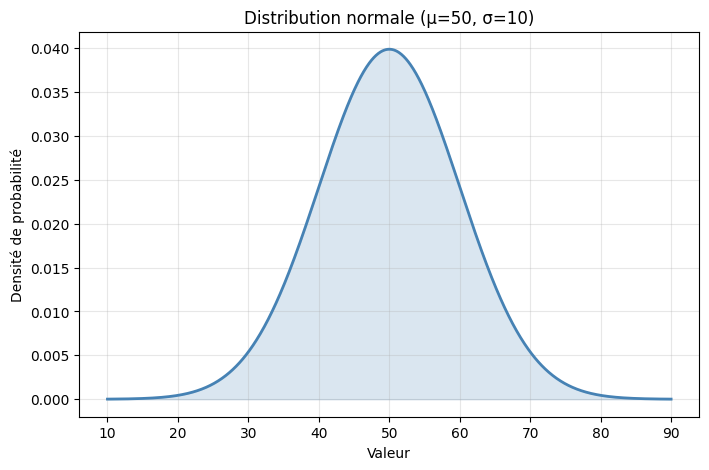

Moyenne de l'échantillon généré : 49.39087556069464
Écart-type de l'échantillon généré : 9.911113611351125


In [3]:
# Exercice 3 : Génération et visualisation d'une distribution normale
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Paramètres de la distribution
mu = 50      # moyenne
sigma = 10   # écart-type

# Génération de 1000 points x sur une plage couvrant ~4 écarts-types
# autour de la moyenne (là où se concentre presque toute la "masse" de la courbe)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Calcul de la densité de probabilité (PDF) pour chaque valeur de x
y = norm.pdf(x, mu, sigma)

# Visualisation
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='steelblue', linewidth=2)
plt.fill_between(x, y, alpha=0.2, color='steelblue')
plt.title(f"Distribution normale (μ={mu}, σ={sigma})")
plt.xlabel("Valeur")
plt.ylabel("Densité de probabilité")
plt.grid(alpha=0.3)
plt.show()

# Bonus : on peut aussi générer un échantillon ALÉATOIRE qui suit cette loi
echantillon = norm.rvs(loc=mu, scale=sigma, size=1000)
print("Moyenne de l'échantillon généré :", np.mean(echantillon))
print("Écart-type de l'échantillon généré :", np.std(echantillon, ddof=1))

In [6]:
# Exercice 4 : Test T sur deux échantillons indépendants
import numpy as np
from scipy import stats

# Génération de deux échantillons aléatoires (loi normale)
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

# Test T pour échantillons indépendants
# H0 (hypothèse nulle) : les deux moyennes sont égales
# H1 (hypothèse alternative) : les deux moyennes sont différentes
t_stat, p_value = stats.ttest_ind(data1, data2)

print(f"Statistique T : {t_stat:.4f}")
print(f"P-value       : {p_value:.6f}")

# Interprétation automatique avec un seuil alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print("\n→ On rejette H0 : la différence entre les deux groupes est statistiquement significative.")
else:
    print("\n→ On ne peut pas rejeter H0 : pas de différence significative détectée.")

# Bonus : visualiser pour confirmer intuitivement
print(f"\nMoyenne data1 : {np.mean(data1):.2f}")
print(f"Moyenne data2 : {np.mean(data2):.2f}")

Statistique T : -7.5195
P-value       : 0.000000

→ On rejette H0 : la différence entre les deux groupes est statistiquement significative.

Moyenne data1 : 48.84
Moyenne data2 : 59.74


In [7]:
# Exercice 5 : Régression linéaire avec SciPy
import numpy as np
from scipy import stats

house_sizes = np.array([50, 70, 80, 100, 120])
house_prices = np.array([150000, 200000, 210000, 250000, 280000])

# linregress calcule la droite de régression : y = slope * x + intercept
resultat = stats.linregress(house_sizes, house_prices)

slope = resultat.slope
intercept = resultat.intercept
r_value = resultat.rvalue
p_value = resultat.pvalue

print(f"Pente (slope)        : {slope:.2f}")
print(f"Ordonnée à l'origine  : {intercept:.2f}")
print(f"Coefficient R²        : {r_value**2:.4f}")
print(f"P-value               : {p_value:.6f}")

# Prédiction pour une maison de 90 m²
taille_a_predire = 90
prix_predit = slope * taille_a_predire + intercept
print(f"\nPrix prédit pour {taille_a_predire} m² : {prix_predit:,.2f}")

Pente (slope)        : 1828.77
Ordonnée à l'origine  : 64383.56
Coefficient R²        : 0.9884
P-value               : 0.000531

Prix prédit pour 90 m² : 228,972.60


In [8]:
# Exercice 6 : ANOVA à un facteur
from scipy import stats

fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

# H0 : les trois fertilisants ont le même effet moyen sur la croissance
# H1 : au moins un fertilisant a un effet différent
f_stat, p_value = stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)

print(f"F-value : {f_stat:.4f}")
print(f"P-value : {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("\n→ On rejette H0 : au moins un fertilisant a un effet significativement différent.")
else:
    print("\n→ On ne peut pas rejeter H0 : pas de différence significative détectée entre les fertilisants.")

F-value : 28.5263
P-value : 0.000028

→ On rejette H0 : au moins un fertilisant a un effet significativement différent.


In [9]:
# Exercice 7 : Distribution binomiale
from scipy.stats import binom

n = 10   # nombre d'essais (lancers de pièce)
p = 0.5  # probabilité de succès à chaque essai (pièce équilibrée)

# Probabilité d'obtenir EXACTEMENT 5 piles sur 10 lancers
proba_exactement_5 = binom.pmf(5, n, p)
print(f"P(exactement 5 piles) : {proba_exactement_5:.4f}")

# Bonus : distribution complète pour 0 à 10 succès
print("\nDistribution complète :")
for k in range(n + 1):
    print(f"P(X={k}) = {binom.pmf(k, n, p):.4f}")

# Bonus 2 : probabilité d'obtenir AU MOINS 5 piles (cumulative)
proba_au_moins_5 = 1 - binom.cdf(4, n, p)
print(f"\nP(au moins 5 piles) : {proba_au_moins_5:.4f}")

P(exactement 5 piles) : 0.2461

Distribution complète :
P(X=0) = 0.0010
P(X=1) = 0.0098
P(X=2) = 0.0439
P(X=3) = 0.1172
P(X=4) = 0.2051
P(X=5) = 0.2461
P(X=6) = 0.2051
P(X=7) = 0.1172
P(X=8) = 0.0439
P(X=9) = 0.0098
P(X=10) = 0.0010

P(au moins 5 piles) : 0.6230


In [10]:
# Exercice 8 : Corrélations de Pearson et Spearman
import pandas as pd
from scipy import stats

data = pd.DataFrame({
    'age': [23, 25, 30, 35, 40],
    'income': [35000, 40000, 50000, 60000, 70000]
})

# Pearson : mesure la relation LINÉAIRE entre les deux variables
pearson_r, pearson_p = stats.pearsonr(data['age'], data['income'])

# Spearman : mesure la relation MONOTONE (basée sur les rangs, pas les valeurs brutes)
spearman_r, spearman_p = stats.spearmanr(data['age'], data['income'])

print(f"Corrélation de Pearson  : {pearson_r:.4f} (p-value = {pearson_p:.4f})")
print(f"Corrélation de Spearman : {spearman_r:.4f} (p-value = {spearman_p:.4f})")

Corrélation de Pearson  : 0.9997 (p-value = 0.0000)
Corrélation de Spearman : 1.0000 (p-value = 0.0000)
